In [13]:
import torch
import matplotlib.pyplot as plt
from torch import nn
print("Gpu enabled: ",torch.cuda.is_available())
print("Version",torch.__version__)

Gpu enabled:  True
Version 2.11.0+cu128


In [14]:
weight = 50 # 
bias = 10000

start=500
end=2100
step=100

X = torch.arange(start,end,step, dtype=torch.float32).reshape(16,1) # area of house
X_normalized = (X - X.min()) / (X.max() - X.min())
noise = torch.randn_like(X.float()) * 1000 # random noise ( because real world data is more scattered )
y = weight * X_normalized + bias + noise # monthly rent


X_normalized[:10], y[:10]


(tensor([[0.0000],
         [0.0667],
         [0.1333],
         [0.2000],
         [0.2667],
         [0.3333],
         [0.4000],
         [0.4667],
         [0.5333],
         [0.6000]]),
 tensor([[11926.9150],
         [11490.6172],
         [10907.3838],
         [ 7904.4790],
         [10691.7520],
         [ 8782.1221],
         [ 9976.9326],
         [ 8418.6660],
         [ 9274.5312],
         [11678.7227]]))

In [ ]:
split_percentage = int(0.8* len(X_normalized))

x_train, y_train = X_normalized[:split_percentage], y[:split_percentage]
x_test, y_test = X_normalized[split_percentage:], y[split_percentage:]

len(x_train), len(y_train), len(x_test), len(y_test)
x_train, y_train

(12, 12, 4, 4)

TypeError: 'float' object cannot be interpreted as an integer

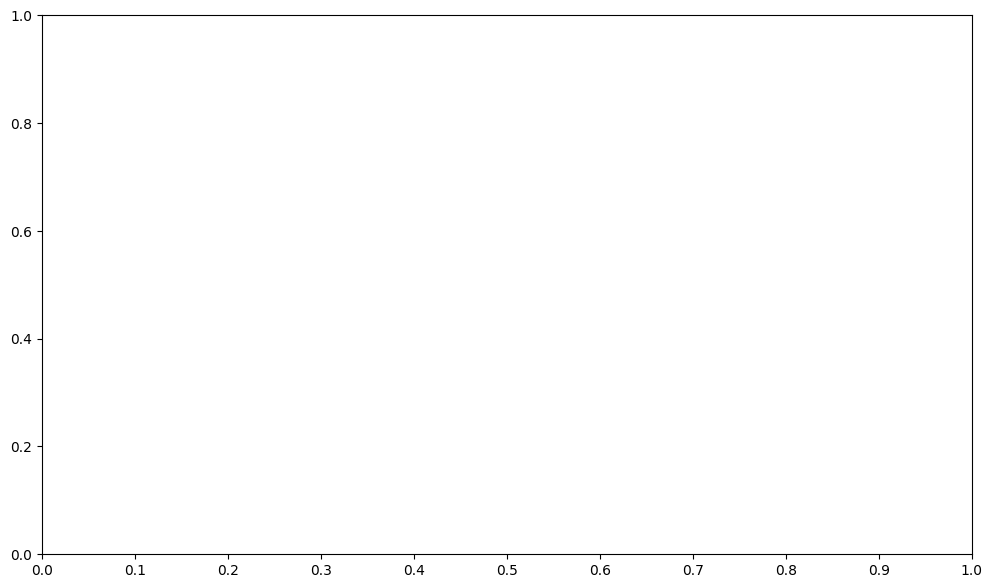

In [ ]:
def plot_graph(x_train=x_train,y_train=y_train, x_test=x_test, y_test=y_test, predictions=None):
    plt.figure(figsize=(12,7))
    
    plt.xticks(torch.arange(0, 1.1, 0.1))
    plt.yticks(torch.arange(0, 1.1, 0.1))  
    
    
    plt.scatter(x_train,y_train,s=10,c="b",label="Training Dataset")
    plt.scatter(x_test,y_test,s=10,c="r",label="Test Dataset")
    
    if predictions is not None:
        plt.scatter(x_test,predictions,s=10,c="g",label="Model Predictions")
        
    plt.legend(prop={"size":12})
        
    

plot_graph()

In [17]:
class HouseRentModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))
        
    def forward(self, x:torch.Tensor):
        return self.weights * x + self.bias
    

model = HouseRentModel()
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.4617]), 'bias': tensor([0.2674])})
[Parameter containing:
tensor([0.4617], requires_grad=True), Parameter containing:
tensor([0.2674], requires_grad=True)]


tensor([[0.6367],
        [0.6675],
        [0.6982],
        [0.7290]])


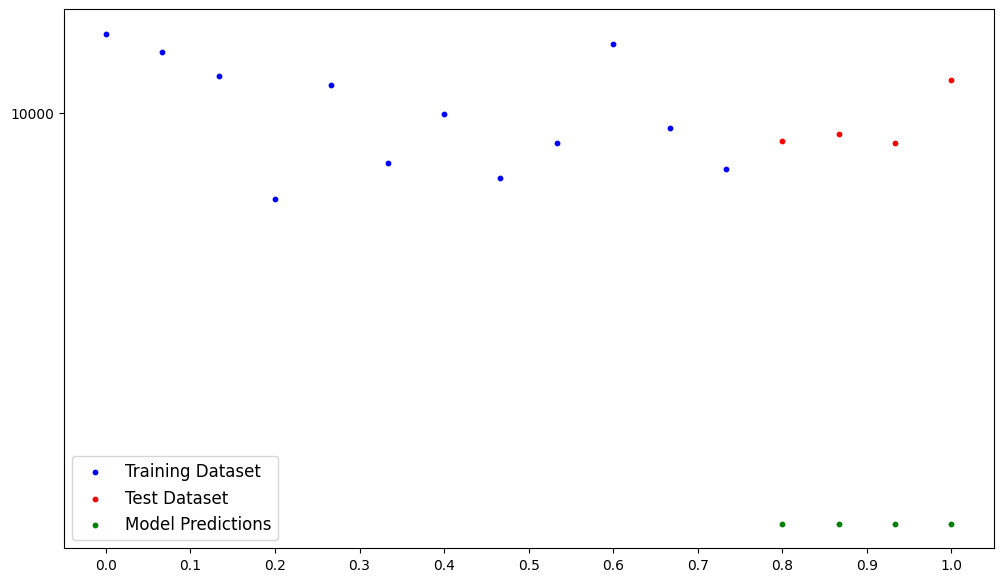

In [18]:
torch.manual_seed(42)

with torch.inference_mode():
    model_predictions = model(x_test)
    print(model_predictions)
    plot_graph(predictions=model_predictions)

In [19]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.000001)

In [20]:
epochs = 5000

for epoch in range(epochs):
    model.train()
    
    y_pred = model(x_train)
    loss = loss_fn(y_pred,y_train)
    
    optimizer.zero_grad()
    loss.backward()
    
    optimizer.step()
    
    if epoch % 5000 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")    

Epoch: 0 | Loss: 9943.3994140625


OrderedDict({'weights': tensor([0.4634]), 'bias': tensor([0.2724])})
tensor([[0.6432],
        [0.6741],
        [0.7050],
        [0.7359]])


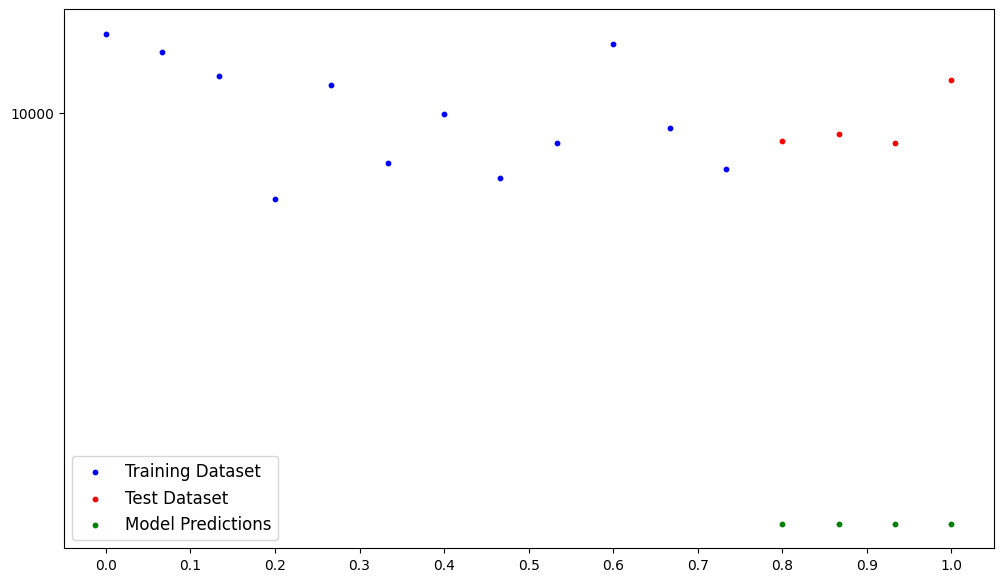

In [21]:
print(model.state_dict())

with torch.inference_mode():
    y_preds = model(x_test)

print(y_preds)
plot_graph(predictions=y_preds)